<a href="https://colab.research.google.com/github/raufur-simanto/Boreal-Forest-Fire-Detection-with-Vision-Mamba/blob/main/notebooks/01_dataset_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1: Dataset Preparation

**Goal:** Prepare the Boreal Forest Fire Dataset for training

**Tasks:**
1. Mount Google Drive and verify dataset structure
2. Count images per location
3. Create location-based train/val/test splits
4. Organize data into YOLO-compatible structure
5. Visualize samples with bounding boxes

**Dataset Structure:**
```
Boreal-Forest-Fire-Subset-A/
├── Evo-Images/          # Train/Val
├── Evo-Labels/
├── Heinola-Images/      # Train/Val
├── Heinola-Labels/
├── Karkkila-Images/     # Train/Val
├── Karkkila-Labels/
├── Ruokolahti-Images/   # Test (geographically separate)
├── Ruokolahti-Labels/
├── Empty-Images/        # Negative examples (Train/Val)
├── Empty-Labels/
└── image_counts.txt
```

## 1. Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

# Verify GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

CUDA available: True
GPU: Tesla T4
Memory: 15.64 GB


In [3]:
# Install required packages
!pip install ultralytics opencv-python matplotlib pillow pyyaml tqdm -q
print("✅ Packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.7 MB/s eta 0:00:00
✅ Packages installed!


In [4]:
# Imports
import os
import shutil
from pathlib import Path
import random
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import yaml

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("✅ Imports complete!")

✅ Imports complete!


## 2. Dataset Inspection

In [5]:
# Define paths
DATASET_ROOT = Path('/content/drive/MyDrive/Boreal-Forest-Fire/Boreal-Forest-Fire-Subset-A')
OUTPUT_ROOT = Path('/content/drive/MyDrive/thesis/data/boreal')

# Verify dataset exists
assert DATASET_ROOT.exists(), f"Dataset not found at {DATASET_ROOT}"
print(f"✅ Dataset found at: {DATASET_ROOT}")

# List contents
print("\nDataset contents:")
for item in sorted(DATASET_ROOT.iterdir()):
    print(f"  {item.name}")

✅ Dataset found at: /content/drive/MyDrive/Boreal-Forest-Fire/Boreal-Forest-Fire-Subset-A

Dataset contents:
  Empty-Images
  Empty-Labels
  Evo-Images
  Evo-Labels
  Heinola-Images
  Heinola-Labels
  Karkkila-Images
  Karkkila-Labels
  Ruokolahti-Images
  Ruokolahti-Labels
  image_counts.txt


In [6]:
# Count images per location
locations = ['Evo', 'Heinola', 'Karkkila', 'Ruokolahti', 'Empty']
image_counts = {}

print("Image counts per location:")
print("=" * 50)

total_images = 0
for loc in locations:
    img_dir = DATASET_ROOT / f'{loc}-Images'
    lbl_dir = DATASET_ROOT / f'{loc}-Labels'

    # Count images (try multiple extensions)
    imgs = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpeg'))
    lbls = list(lbl_dir.glob('*.txt'))

    n_imgs = len(imgs)
    n_lbls = len(lbls)

    image_counts[loc] = n_imgs
    total_images += n_imgs

    print(f"{loc:15s}: {n_imgs:4d} images, {n_lbls:4d} labels")

    # Check for mismatch
    if n_imgs != n_lbls:
        print(f"  ⚠️  Warning: Image/label count mismatch!")

print("=" * 50)
print(f"{'TOTAL':15s}: {total_images:4d} images")
print(f"\nExpected: ~4,954 images")

Image counts per location:
Evo            :  931 images,  931 labels
Heinola        :  906 images,  906 labels
Karkkila       : 1096 images, 1096 labels
Ruokolahti     : 1765 images, 1765 labels
Empty          :  256 images,  256 labels
TOTAL          : 4954 images

Expected: ~4,954 images


In [7]:
# Inspect a sample annotation
sample_label = list((DATASET_ROOT / 'Evo-Labels').glob('*.txt'))[0]

print(f"Sample annotation file: {sample_label.name}")
print("\nContents:")
with open(sample_label, 'r') as f:
    for i, line in enumerate(f):
        print(f"  Line {i+1}: {line.strip()}")
        if i >= 5:  # Show max 5 lines
            print("  ...")
            break

print("\nYOLO format: class x_center y_center width height (normalized 0-1)")

Sample annotation file: evoDJI_0001_frame48.txt

Contents:
  Line 1: 0 0.505665 0.034753 0.154436 0.054002

YOLO format: class x_center y_center width height (normalized 0-1)


## 3. Create Train/Val/Test Splits

**Strategy:**
- **Test:** All Ruokolahti images (geographically separate)
- **Train/Val:** Evo + Heinola + Karkkila + Empty → 80/20 split

In [8]:
# Collect all image/label pairs
def get_image_label_pairs(location):
    """Get all (image, label) file pairs for a location"""
    img_dir = DATASET_ROOT / f'{location}-Images'
    lbl_dir = DATASET_ROOT / f'{location}-Labels'

    pairs = []
    for img_path in img_dir.glob('*'):
        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            # Find corresponding label
            lbl_path = lbl_dir / f"{img_path.stem}.txt"
            if lbl_path.exists():
                pairs.append((img_path, lbl_path))
            else:
                print(f"⚠️  Warning: No label for {img_path.name}")

    return pairs

# Get test set (Ruokolahti)
test_pairs = get_image_label_pairs('Ruokolahti')
print(f"Test set: {len(test_pairs)} images")

# Get train/val set (all other locations)
train_val_pairs = []
for loc in ['Evo', 'Heinola', 'Karkkila', 'Empty']:
    pairs = get_image_label_pairs(loc)
    train_val_pairs.extend(pairs)
    print(f"{loc}: {len(pairs)} images")

print(f"\nTotal train/val: {len(train_val_pairs)} images")

# Shuffle and split train/val (80/20)
random.shuffle(train_val_pairs)
split_idx = int(0.8 * len(train_val_pairs))
train_pairs = train_val_pairs[:split_idx]
val_pairs = train_val_pairs[split_idx:]

print(f"\n📊 Final splits:")
print(f"  Train: {len(train_pairs)} images")
print(f"  Val:   {len(val_pairs)} images")
print(f"  Test:  {len(test_pairs)} images")
print(f"  Total: {len(train_pairs) + len(val_pairs) + len(test_pairs)} images")

Test set: 1765 images
Evo: 931 images
Heinola: 906 images
Karkkila: 1096 images
Empty: 256 images

Total train/val: 3189 images

📊 Final splits:
  Train: 2551 images
  Val:   638 images
  Test:  1765 images
  Total: 4954 images


## 4. Organize Data into YOLO Structure

In [9]:
# Create output directory structure
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

for split in ['train', 'val', 'test']:
    (OUTPUT_ROOT / 'images' / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_ROOT / 'labels' / split).mkdir(parents=True, exist_ok=True)

print("✅ Directory structure created:")
print(OUTPUT_ROOT)
print("├── images/")
print("│   ├── train/")
print("│   ├── val/")
print("│   └── test/")
print("└── labels/")
print("    ├── train/")
print("    ├── val/")
print("    └── test/")

✅ Directory structure created:
/content/drive/MyDrive/thesis/data/boreal
├── images/
│   ├── train/
│   ├── val/
│   └── test/
└── labels/
    ├── train/
    ├── val/
    └── test/


In [10]:
# Copy files to organized structure
def copy_pairs(pairs, split_name):
    """Copy image/label pairs to output directory"""
    img_out_dir = OUTPUT_ROOT / 'images' / split_name
    lbl_out_dir = OUTPUT_ROOT / 'labels' / split_name

    for img_path, lbl_path in tqdm(pairs, desc=f"Copying {split_name}"):
        # Copy with unique names (prefix with location to avoid conflicts)
        shutil.copy2(img_path, img_out_dir / img_path.name)
        shutil.copy2(lbl_path, lbl_out_dir / lbl_path.name)

# Copy all splits
copy_pairs(train_pairs, 'train')
copy_pairs(val_pairs, 'val')
copy_pairs(test_pairs, 'test')

print("\n✅ All files copied!")

Copying test: 100%|██████████| 1765/1765 [27:17<00:00,  1.08it/s]


✅ All files copied!


## 5. Create YOLO Configuration File

In [18]:
# Create data.yaml for YOLO
data_yaml = {
    'path': str(OUTPUT_ROOT),  # Root directory
    'train': 'images/train',   # Relative to path
    'val': 'images/val',
    'test': 'images/test',
    'nc': 1,                   # Number of classes (smoke/fire)
    'names': ['smoke']         # Class names
}

yaml_path = OUTPUT_ROOT / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f" YOLO config saved to: {yaml_path}")
print("\nContents:")
with open(yaml_path, 'r') as f:
    print(f.read())

 YOLO config saved to: /content/drive/MyDrive/thesis/data/boreal/data.yaml

Contents:
names:
- smoke
nc: 1
path: /content/drive/MyDrive/thesis/data/boreal
test: images/test
train: images/train
val: images/val



## 6. Visualize Samples

In [12]:
def visualize_sample(img_path, lbl_path, ax=None):
    """Visualize an image with bounding boxes"""
    # Read image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Read labels
    with open(lbl_path, 'r') as f:
        labels = [line.strip().split() for line in f if line.strip()]

    # Draw bounding boxes
    for label in labels:
        cls, x_center, y_center, width, height = map(float, label)

        # Convert YOLO format to pixel coordinates
        x1 = int((x_center - width/2) * w)
        y1 = int((y_center - height/2) * h)
        x2 = int((x_center + width/2) * w)
        y2 = int((y_center + height/2) * h)

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(img, 'smoke', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                   0.9, (255, 0, 0), 2)

    # Plot
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    ax.imshow(img)
    ax.set_title(f"{img_path.name} ({len(labels)} boxes)")
    ax.axis('off')

    return ax

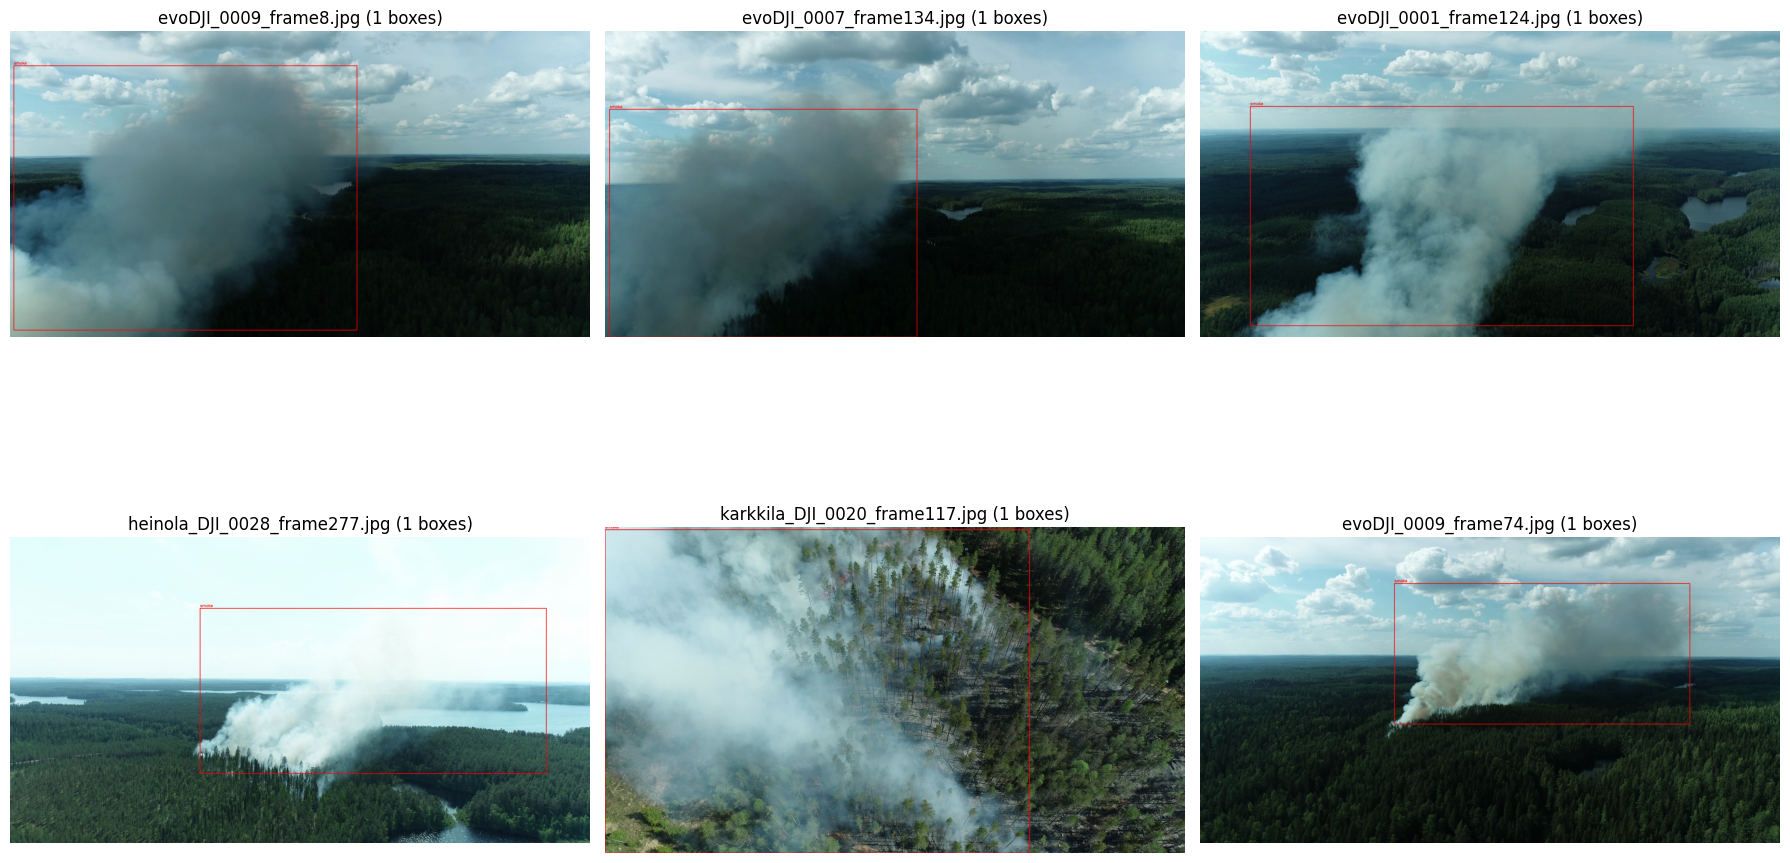

Sample visualization saved!


In [16]:
# Visualize 6 random samples from train set
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

samples = random.sample(train_pairs, 6)

for idx, (img_path, lbl_path) in enumerate(samples):
    visualize_sample(img_path, lbl_path, ax=axes[idx])

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'sample_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample visualization saved!")

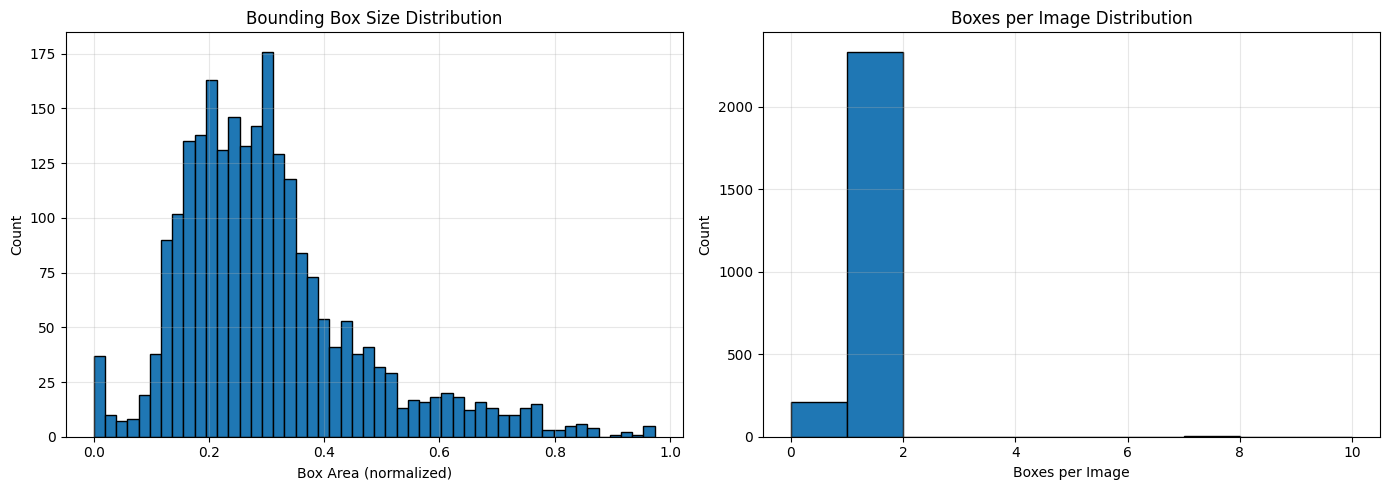

Average box area: 0.3042
Average boxes per image: 0.94
Max boxes in one image: 9


In [14]:
# Analyze bounding box statistics
def analyze_boxes(pairs):
    """Analyze bounding box statistics"""
    box_sizes = []
    box_counts = []

    for img_path, lbl_path in pairs:
        with open(lbl_path, 'r') as f:
            labels = [line.strip().split() for line in f if line.strip()]

        box_counts.append(len(labels))

        for label in labels:
            _, _, _, width, height = map(float, label)
            box_sizes.append(width * height)  # Normalized area

    return box_sizes, box_counts

train_sizes, train_counts = analyze_boxes(train_pairs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box size distribution
axes[0].hist(train_sizes, bins=50, edgecolor='black')
axes[0].set_xlabel('Box Area (normalized)')
axes[0].set_ylabel('Count')
axes[0].set_title('Bounding Box Size Distribution')
axes[0].grid(alpha=0.3)

# Box count per image
axes[1].hist(train_counts, bins=range(max(train_counts)+2), edgecolor='black')
axes[1].set_xlabel('Boxes per Image')
axes[1].set_ylabel('Count')
axes[1].set_title('Boxes per Image Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'box_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average box area: {np.mean(train_sizes):.4f}")
print(f"Average boxes per image: {np.mean(train_counts):.2f}")
print(f"Max boxes in one image: {max(train_counts)}")

## 7. Final Summary

In [15]:
print("="*60)
print("DATASET PREPARATION COMPLETE")
print("="*60)
print(f"\n Output location: {OUTPUT_ROOT}")
print(f"\n Dataset splits:")
print(f"   Train: {len(train_pairs):4d} images")
print(f"   Val:   {len(val_pairs):4d} images")
print(f"   Test:  {len(test_pairs):4d} images (Ruokolahti - geographically separate)")
print(f"   Total: {len(train_pairs) + len(val_pairs) + len(test_pairs):4d} images")
print(f"\n YOLO config: {yaml_path}")
print("="*60)

DATASET PREPARATION COMPLETE

 Output location: /content/drive/MyDrive/thesis/data/boreal

 Dataset splits:
   Train: 2551 images
   Val:    638 images
   Test:  1765 images (Ruokolahti - geographically separate)
   Total: 4954 images

 YOLO config: /content/drive/MyDrive/thesis/data/boreal/data.yaml
